# Decision Making with Business Statistics
###Project: E-News Express

In [2]:
import pandas as pd

# Replace 'your_file.csv' with the uploaded filename shown in the Files panel
path = "/content/sample_data/abtest.csv"
df = pd.read_csv(path)

# Quick check
print(df.shape)
df.head()

(100, 6)


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [3]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 80.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
df.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [6]:
df.shape

(100, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


**Getting the statistical summary for the numerical variables**

In [8]:
# write your code here to print the numerical summary statistics
df.describe(include='all')

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
count,100.000000,100,100,100.000000,100,100
unique,NaN,2,2,NaN,2,3
top,NaN,control,old,NaN,yes,Spanish
freq,NaN,50,50,NaN,54,34
mean,546517.000000,NaN,NaN,5.377800,NaN,NaN
std,52.295779,NaN,NaN,2.378166,NaN,NaN
min,546443.000000,NaN,NaN,0.190000,NaN,NaN
25%,546467.750000,NaN,NaN,3.880000,NaN,NaN
50%,546492.500000,NaN,NaN,5.415000,NaN,NaN
75%,546567.250000,NaN,NaN,7.022500,NaN,NaN


In [9]:
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    print(f"Summary for: {col}")
    print(df[col].describe())
    print("\n")

Summary for: user_id
count       100.000000
mean     546517.000000
std          52.295779
min      546443.000000
25%      546467.750000
50%      546492.500000
75%      546567.250000
max      546592.000000
Name: user_id, dtype: float64


Summary for: time_spent_on_the_page
count    100.000000
mean       5.377800
std        2.378166
min        0.190000
25%        3.880000
50%        5.415000
75%        7.022500
max       10.710000
Name: time_spent_on_the_page, dtype: float64




In [10]:
df.describe(include=['object'])

,group,landing_page,converted,language_preferred
count,100,100,100,100
unique,2,2,2,3
top,control,old,yes,Spanish
freq,50,50,54,34


**Getting the statistical summary for the categorical variables**

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"Summary for: {col}")
    print(df[col].describe())
    print("\n")

Summary for: group
count         100
unique          2
top       control
freq           50
Name: group, dtype: object


Summary for: landing_page
count     100
unique      2
top       old
freq       50
Name: landing_page, dtype: object


Summary for: converted
count     100
unique      2
top       yes
freq       54
Name: converted, dtype: object


Summary for: language_preferred
count         100
unique          3
top       Spanish
freq           34
Name: language_preferred, dtype: object




In [12]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"Value counts for: {col}")
    print(df[col].value_counts())
    print("\n")

Value counts for: group
group
control      50
treatment    50
Name: count, dtype: int64


Value counts for: landing_page
landing_page
old    50
new    50
Name: count, dtype: int64


Value counts for: converted
converted
yes    54
no     46
Name: count, dtype: int64


Value counts for: language_preferred
language_preferred
Spanish    34
French     34
English    32
Name: count, dtype: int64




In [17]:
df.isnull().sum()


,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


In [19]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_summary

,Missing Values,Percentage (%)
user_id,0,0.0
group,0,0.0
landing_page,0,0.0
time_spent_on_the_page,0,0.0
converted,0,0.0
language_preferred,0,0.0


In [20]:
df.isnull().values.any()

np.False_

"Hense there is no missing values in the data"

**Check for missing values**

In [21]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
missing_summary

,Missing Values,Percentage (%)
user_id,0,0.0
group,0,0.0
landing_page,0,0.0
time_spent_on_the_page,0,0.0
converted,0,0.0
language_preferred,0,0.0


In [22]:
df.isnull().values.any()


np.False_

"No missing value found"

**"Checking for duplicates"**

In [24]:
df.duplicated().any()

np.False_

**"Here no duplicate value found and no need to remove duplicate rows"**

# Univariate Analysis

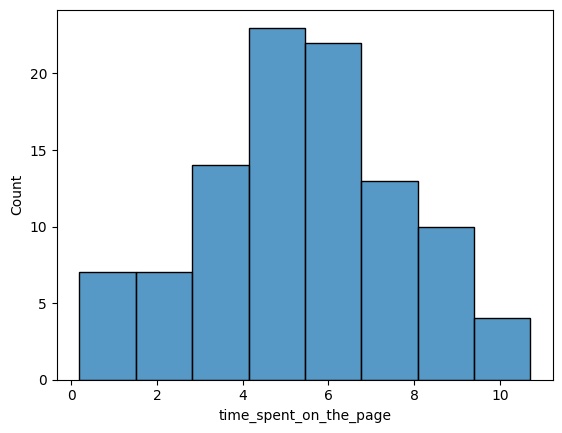

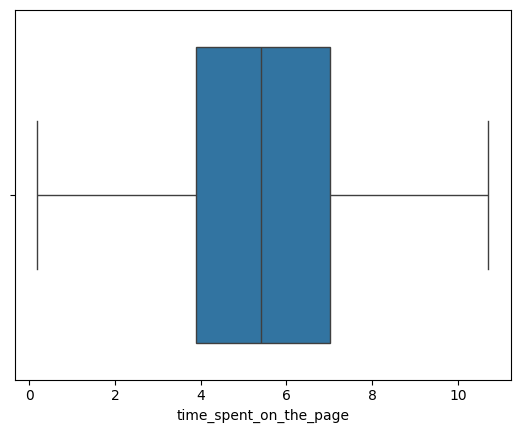

In [28]:
sns.histplot(data=df,x='time_spent_on_the_page')
plt.show()
sns.boxplot(data=df,x='time_spent_on_the_page')
plt.show()

In [29]:
df['group'].value_counts()


,count
group,
control,50
treatment,50


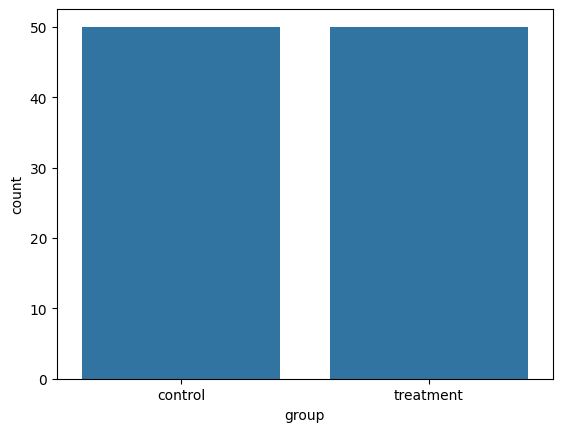

In [30]:
sns.countplot(data=df,x='group')
plt.show()

In [31]:
df['landing_page'].value_counts()

,count
landing_page,
old,50
new,50


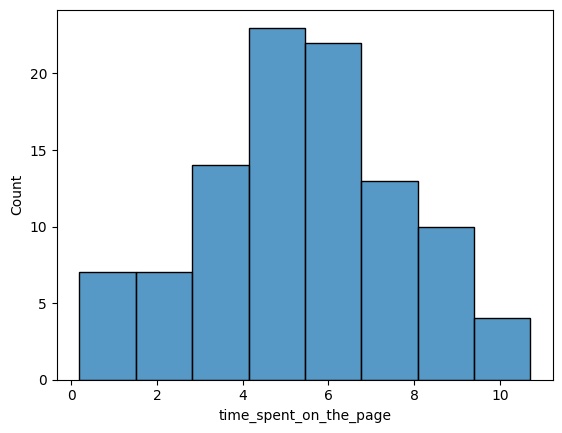

In [37]:
sns.histplot(data=df,x='time_spent_on_the_page')
plt.show()

In [38]:
df['converted'].value_counts()

,count
converted,
yes,54
no,46


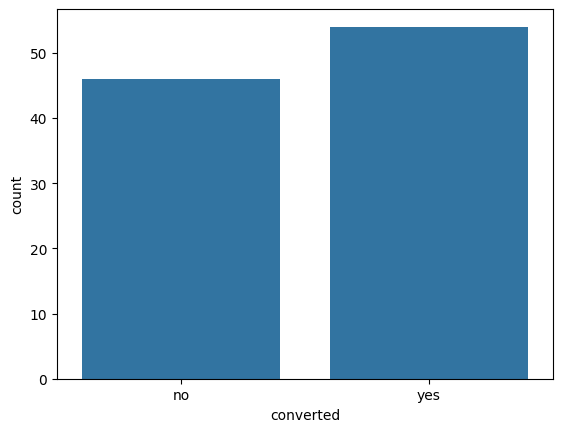

In [40]:
df['converted'].value_counts()

# complete the code to plot the countplot
sns.countplot(data=df, x='converted')
plt.show()


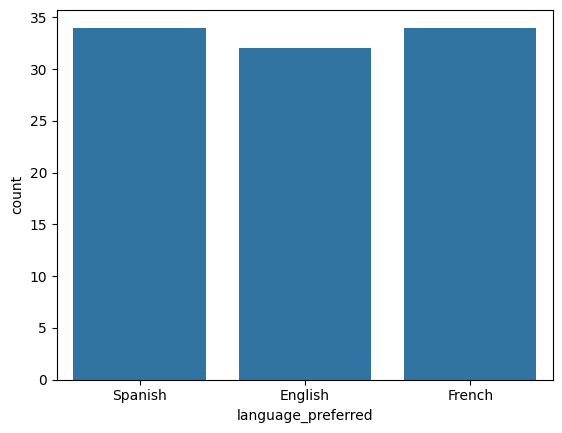

In [41]:
df['language_preferred'].value_counts()

# complete the code to plot the countplot
sns.countplot(data=df, x='language_preferred')
plt.show()


# BIVARIATE ANALYSIS
### Landing page vs Time spent

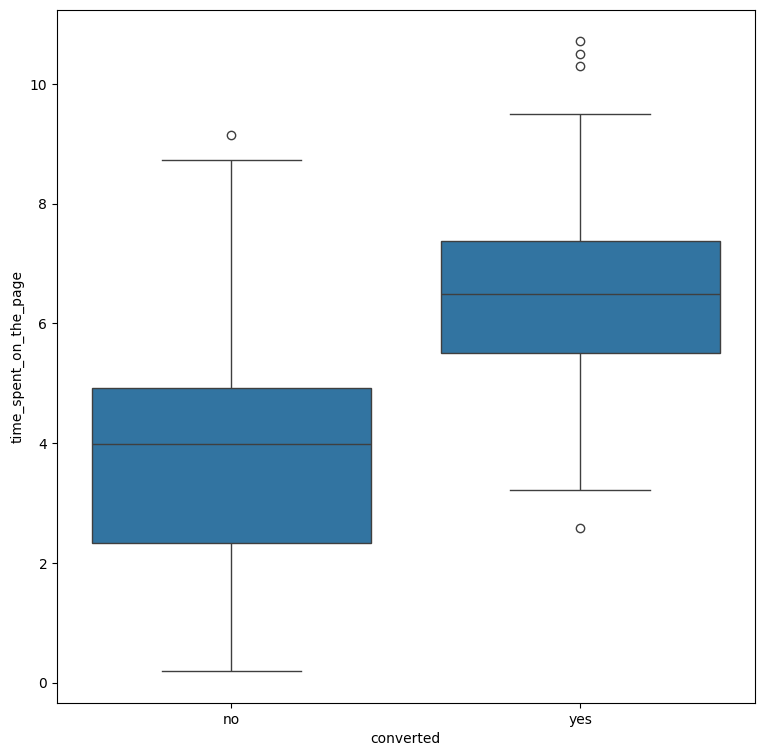

In [42]:
plt.figure(figsize=(9, 9))
sns.boxplot(data=df, x='converted', y='time_spent_on_the_page')
plt.show()

###Conversion status vs Time spent

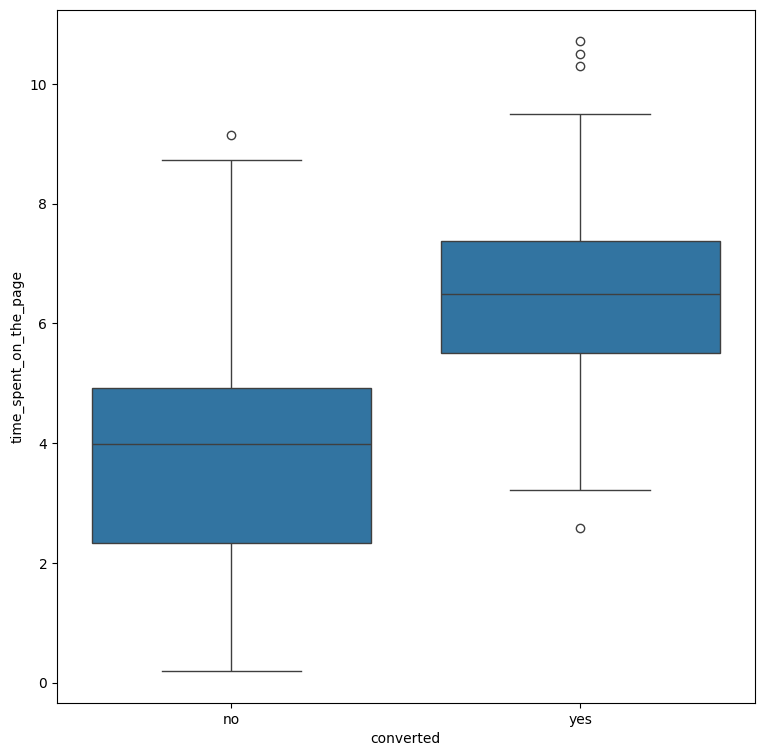

In [43]:
plt.figure(figsize=(9, 9))
sns.boxplot(data=df, x='converted', y='time_spent_on_the_page')
plt.show()


###Language preferred vs Time spent

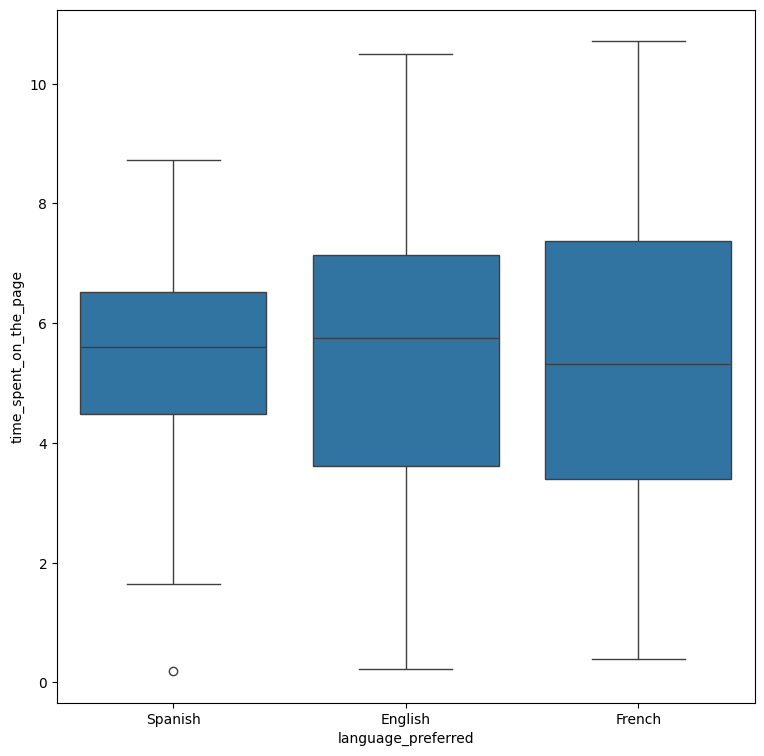

In [44]:
plt.figure(figsize=(9, 9))
sns.boxplot(data=df, x='language_preferred', y='time_spent_on_the_page')
plt.show()

# 1. Do the users spend more time on the new landing page than the existing landing page?

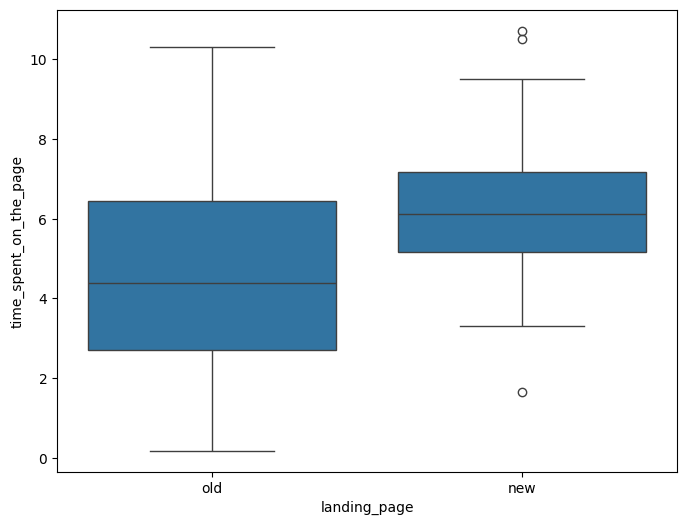

In [46]:
plt.figure(figsize=(8,6))
sns.boxplot(x = 'landing_page', y = 'time_spent_on_the_page', data = df)
plt.show()

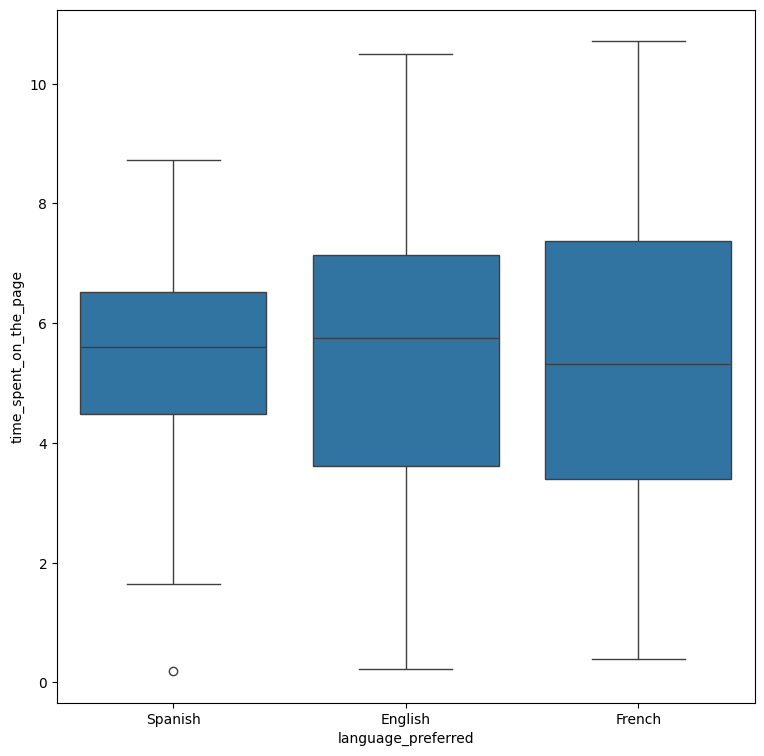

In [45]:
plt.figure(figsize=(9, 9))
sns.boxplot(data=df, x='language_preferred', y='time_spent_on_the_page')
plt.show()


Hence the French language preferable that the most time spent on.

Hypotheses

H0: Mean time spent on new page ≤ mean time spent on old page

Ha: Mean time spent on new page > mean time spent on old page

In [50]:
#Data Preparation steps

time_spent_new = df[df['landing_page'] == 'new']['time_spent_on_the_page']

time_spent_old = df[df['landing_page'] == 'old']['time_spent_on_the_page']  # filled

print('The sample standard deviation of the time spent on the new page is:', round(time_spent_new.std(),2))
print('The sample standard deviation of the time spent on the old page is:', round(time_spent_old.std(),2))


The sample standard deviation of the time spent on the new page is: 1.82
The sample standard deviation of the time spent on the old page is: 2.58


In [52]:
#Statistical Test
# complete the code to import the required function
from scipy.stats import ttest_ind

# write the code to calculate the p-value
test_stat, p_value = ttest_ind(
    time_spent_new,
    time_spent_old,
    equal_var=False,            # std dev likely unequal
    alternative='greater'       # one-tailed test
)

print('The p-value is', p_value)


The p-value is 0.0001392381225166549


In [54]:
#Compare the p-value with α

# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.0001392381225166549 is less than the level of significance, we reject the null hypothesis.


#Drawing inference

Reference:P-value > \(\alpha \) (e.g., 0.05001): You fail to reject the null hypothesis. The results are considered not statistically significant at that pre-determined \(\alpha \) level [1, 2].P-value \(\le \) \(\alpha \) (e.g., 0.05 or 0.0499): You reject the null hypothesis and conclude there is a statistically significant effect [1, 2].

Hence: we reject the null hypothesis.


## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

Visual Comparison


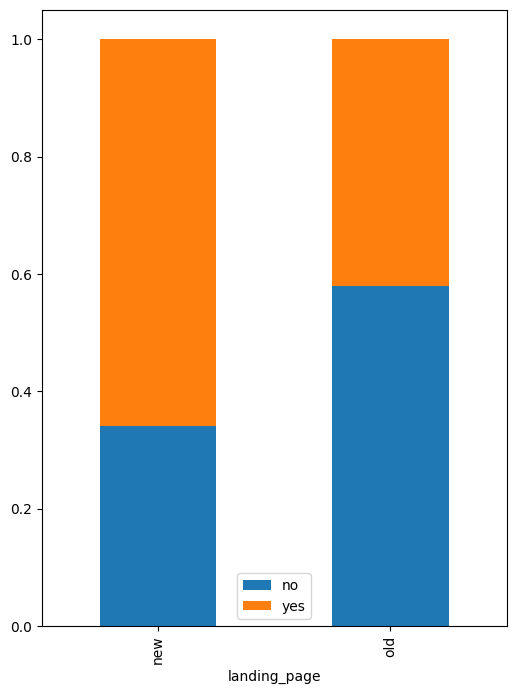

In [55]:
pd.crosstab(df['landing_page'], df['converted'], normalize='index').plot(
    kind="bar", figsize=(6,8), stacked=True)
plt.legend()
plt.show()


Hypotheses

H0: Conversion rate (new) ≤ Conversion rate (old)

Ha: Conversion rate (new) > Conversion rate (old)




In [58]:
#Prepare Data

new_converted = df[df['group'] == 'treatment']['converted'].value_counts()['yes']
old_converted = df[df['group'] == 'control']['converted'].value_counts()['yes']

n_control = df.group.value_counts()['control']
n_treatment = df.group.value_counts()['treatment']

print('The numbers of users served the new and old pages are {0} and {1} respectively'.format(n_control, n_treatment ))


The numbers of users served the new and old pages are 50 and 50 respectively


In [57]:
#Statistical Test

from statsmodels.stats.proportion import proportions_ztest

test_stat, p_value = proportions_ztest(
    [new_converted, old_converted],
    [n_treatment, n_control],
    alternative='larger'
)

print('The p-value is', p_value)


The p-value is 0.008026308204056278


In [61]:
# calculate the number of converted users in the treatment group
new_converted = df[df['group'] == 'treatment']['converted'].value_counts()['yes']
# calculate the number of converted users in the control group
old_converted = df[df['group'] == 'treatment']['converted'].value_counts()['yes'] # complete your code here

n_control = df.group.value_counts()['control'] # total number of users in the control group
n_treatment = df.group.value_counts()['treatment'] # total number of users in the treatment group

print('The numbers of users served the new and old pages are {0} and {1} respectively'.format(n_control, n_treatment ))

The numbers of users served the new and old pages are 50 and 50 respectively


In [62]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.008026308204056278 is less than the level of significance, we reject the null hypothesis.


Draw inference

The reference value is < 0.05, hense we reject the null hypothesis.

#3. Does the converted status depend on the preferred language?

Perform Visual Analysis


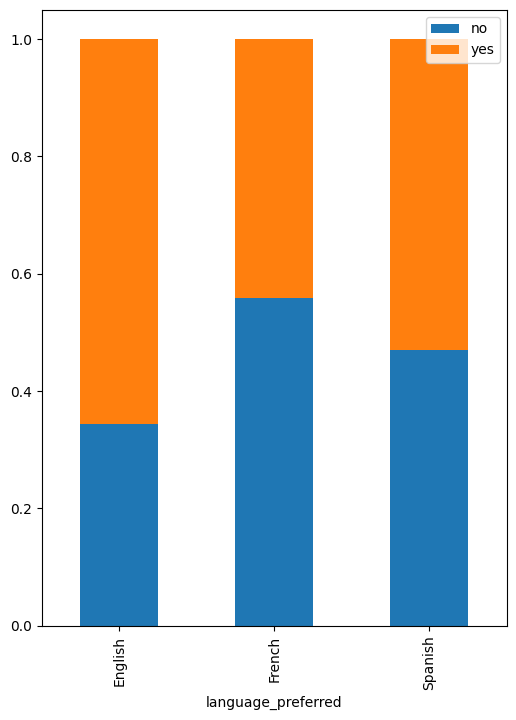

In [63]:
pd.crosstab(df['language_preferred'], df['converted'], normalize='index').plot(
    kind="bar", figsize=(6,8), stacked=True)
plt.legend()
plt.show()


#Hypotheses

H0: Converted status is independent of language

Ha: Converted status depends on language

Contingency Table

In [64]:
contingency_table = pd.crosstab(df['language_preferred'], df['converted'])
contingency_table

converted,no,yes
language_preferred,,
English,11,21
French,19,15
Spanish,16,18


In [66]:
# Selection of the Chi-Square Test as the it is used for categorical data to see if observed frequencies
#differ significantly from expected frequencies

from scipy.stats import chi2_contingency

chi2, p_value, dof, exp_freq = chi2_contingency(contingency_table)

print('The p-value is', p_value)


The p-value is 0.2129888748754345


In [67]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')


As the p-value 0.2129888748754345 is greater than the level of significance, we fail to reject the null hypothesis.


###Drawing inference: we fail to reject the null hypothesis.



#4. Is the time spent on the new page same for the different language users?

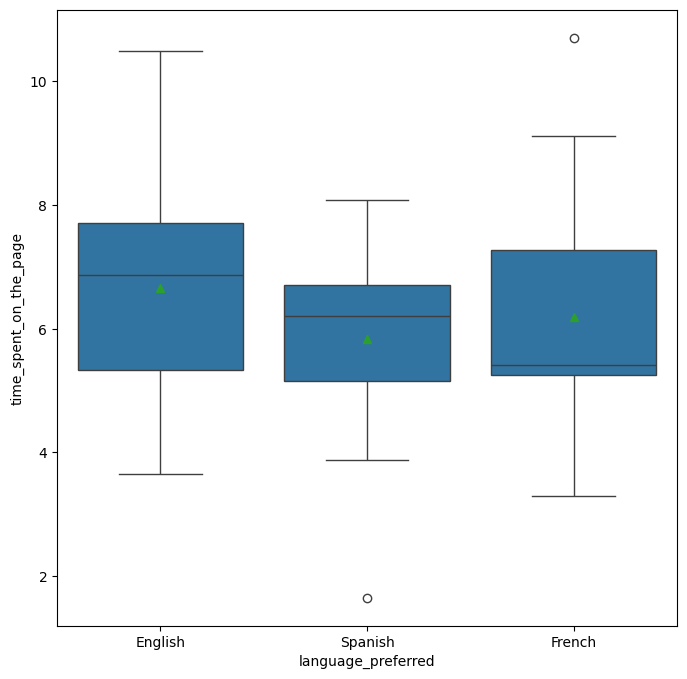

In [68]:
df_new = df[df['landing_page'] == 'new']

plt.figure(figsize=(8,8))
sns.boxplot(x='language_preferred', y='time_spent_on_the_page', showmeans=True, data=df_new)
plt.show()


In [70]:
df_new.groupby(['language_preferred'])['time_spent_on_the_page'].mean()


,time_spent_on_the_page
language_preferred,
English,6.663750
French,6.196471
Spanish,5.835294


Hypotheses

H0: All language groups have equal average time on new page

Ha: At least one language group differs

###Prepare Data

In [72]:
time_spent_English = df_new[df_new['language_preferred']=="English"]['time_spent_on_the_page']
time_spent_French = df_new[df_new['language_preferred']=="French"]['time_spent_on_the_page']
time_spent_Spanish = df_new[df_new['language_preferred']=="Spanish"]['time_spent_on_the_page']


In [73]:
from scipy.stats import f_oneway

test_stat, p_value = f_oneway(time_spent_English, time_spent_French, time_spent_Spanish)

print('The p-value is', p_value)


The p-value is 0.43204138694325955


In [74]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.43204138694325955 is greater than the level of significance, we fail to reject the null hypothesis.


###Drawing inference: The value of P is greater than the level of significance, we fail to reject the null hypothesis.

#Conclusion and Business Recommendations

---



1. The analysis confirms that users spend significantly more time on the new landing page than the old one, indicating stronger engagement.

2. The new landing page also demonstrates a higher conversion rate, proving its effectiveness in driving new subscriber growth.

3. User conversion behavior varies across preferred languages, highlighting a dependency between language choice and subscription likelihood.

4. Time spent on the new landing page differs significantly among English, French, and Spanish users, indicating unequal engagement levels.

5. Based on these insights, the new landing page should be implemented as the default experience for all incoming visitors.

6. Language-specific optimization is required to improve engagement and conversion among lower-performing language groups.

7. The company should enhance translation quality and tailor content to cultural nuances for better resonance with different user segments.

8. Continuous A/B testing should be adopted to refine CTAs, content layout, and subscription prompts to maximize performance over time.

9. Personalized content recommendations should be integrated to further increase user involvement and reduce bounce rates.

10. Post-launch monitoring of key metrics such as conversion rate, time-on-page, and language-wise engagement will be essential for ongoing improvement.